# IMC Prosperity 4: Round 2

This research notebook analyses the historical order book and trade data for *ASH_COATED_OSMIUM* and *INTARIAN_PEPPER_ROOT* across days -1, 0 and 1.

The goal is twofolds: 
- refine the trading logic from round 1  
- decide how much to bid for **Market access fee**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import json
from io import StringIO

In [2]:
# Set plotting style and display options
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

## 1. Round 2 objective and notebook roadmap

Round 2 extends the round 1 market making problem in two ways.

First, we still need to trade `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM` profitably under the same **80 unit position limit** in each product.

Second, we now face a **blind auction** for extra market access. Accepted bidders receive access to **25% more quotes**, but they also pay their bid as a one off fee. Because only the top 50% of bidders are accepted, the correct bid is not necessarily our maximum willingness to pay. It is the lowest bid that gives a good chance of clearing the median while preserving most of the value of access.

This notebook therefore aims to answer three concrete questions:

1. what is the right trading logic for each product  
2. how much is extra market access worth to our strategy  
3. what working round 2 submission should we use, including model code and a Market Access Fee bid

## 2. Round 1 retrospective

### 2.1 Round 1 performance

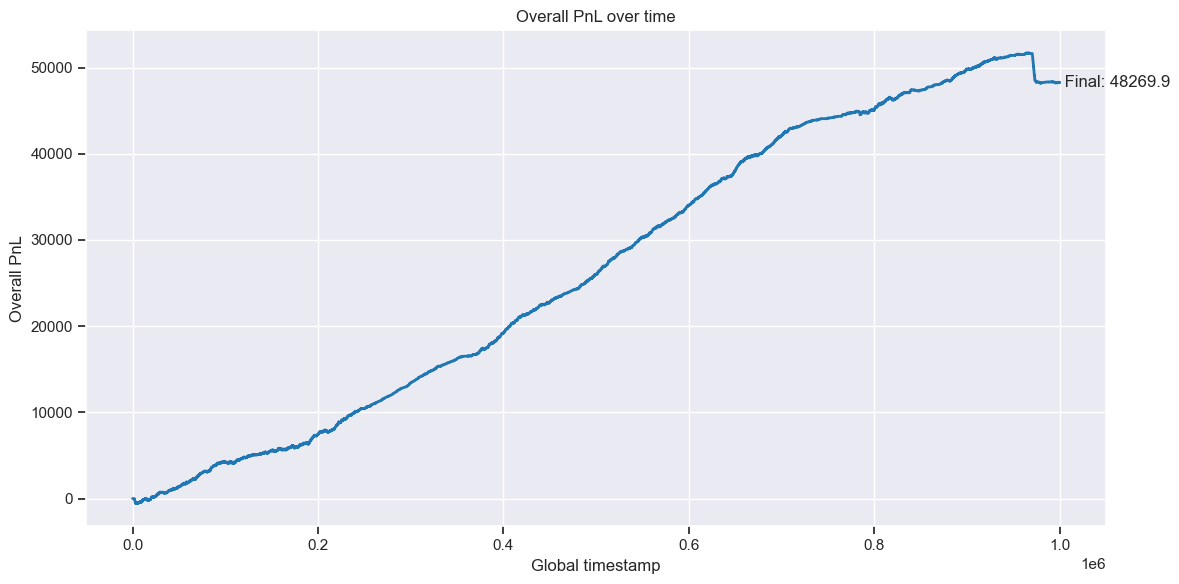

In [3]:
DAY_LENGTH = 1_000_000

path = "data/r1_test.log"
with open(path, "r", encoding="utf-8") as f:
    raw_r1 = json.load(f)

df_performance_r1 = pd.read_csv(StringIO(raw_r1["activitiesLog"]), sep=";")

df_performance_r1["global_timestamp"] = (df_performance_r1["day"] - df_performance_r1["day"].min()) * DAY_LENGTH + df_performance_r1["timestamp"]

overall_pnl = (
    df_performance_r1.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

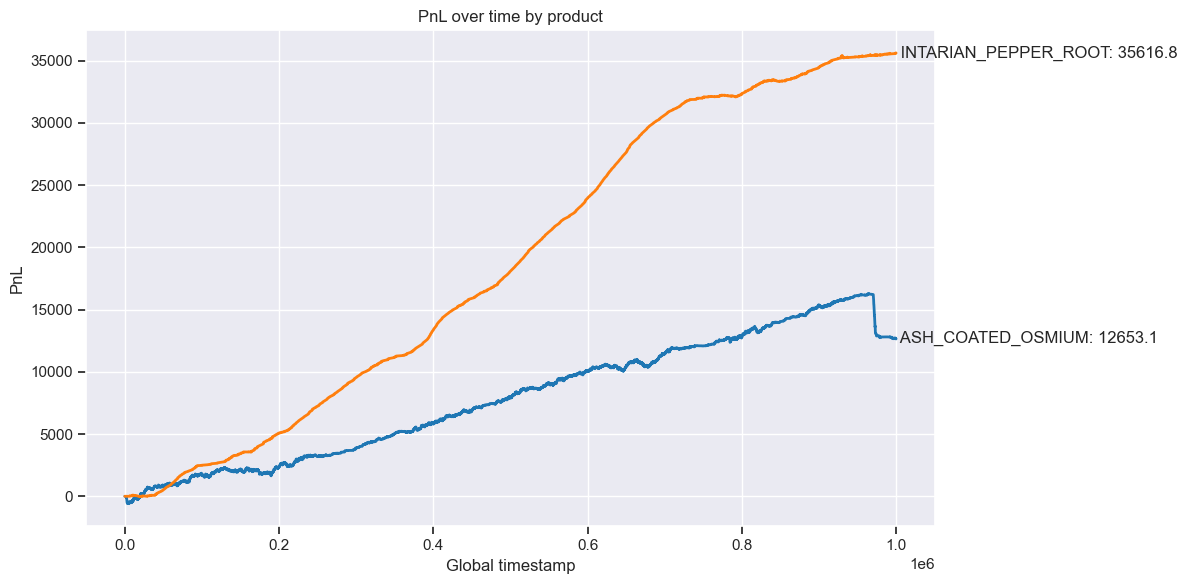

In [4]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_r1.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [5]:
df_trades_r1 = pd.DataFrame(raw_r1['tradeHistory'])

df_trades_r1['signed_qty']=np.where(df_trades_r1['buyer']=='SUBMISSION', df_trades_r1['quantity'],
                                     np.where(df_trades_r1['seller']=='SUBMISSION', -df_trades_r1['quantity'], 0))
df_trades_r1['cashflow']= -df_trades_r1['signed_qty']*df_trades_r1['price'] 

metrics = {}

for prod,g in df_trades_r1.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    pos = g['signed_qty'].cumsum()
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': pos.abs().max(),
        'cash_pnl': g['cashflow'].sum(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl
ASH_COATED_OSMIUM,799.0,334.0,351.0,1800.0,1790.0,9994.794444,10001.871508,10.0,80.0,-87280.0
INTARIAN_PEPPER_ROOT,579.0,255.0,252.0,1327.0,1325.0,13508.721176,13534.860377,2.0,80.0,7617.0


Drawdowns:

In [6]:
df_performance_r1_wide = df_performance_r1.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_r1_wide['total']=df_performance_r1_wide.sum(axis=1)
dd = df_performance_r1_wide['total'] - df_performance_r1_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_r1_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,12653.054688,16301.695312,-591.187500,-3661.820312,999800.0
INTARIAN_PEPPER_ROOT,35616.800781,35616.800781,-37.203125,-197.000000,931400.0
total,48269.855469,51706.093750,-591.187500,-3517.804688,979600.0


Round 1 showed that profitability depended less on building a very complicated signal stack and more on correctly identifying the dominant behaviour of each product and executing around it cleanly. Our submitted version achieved a PnL of **48,270**, which was respectable but there is still way more edge to be captured.

The main lesson from the round 1 results was that **INTARIAN_PEPPER_ROOT** appeared to offer a strong directional opportunity. In hindsight, a simpler strategy with an early long bias and limited unnecessary turnover may have captured a larger share of the available move. So this time we will test monetising this trend more directly, rather than relying too heavily on short horizon reactive logic.

By contrast, **ASH_COATED_OSMIUM** appeared less attractive as a large directional trade and more suited to tighter execution, inventory control and possibly short horizon market making or mean reversion. This means the two products should not be treated symmetrically in round 2 either. One of the key improvements in this notebook is therefore to separate the research process by product and only then combine them into a single algorithm.

A second lesson is that **execution quality likely mattered more than model complexity**. If the dominant edge in pepper was broad directional drift, then overtrading, quoting both sides too passively or repeatedly fading the move may all have reduced realised PnL. Similarly, in osmium, weak inventory management or poorly calibrated aggressiveness may have limited the strategy’s ability to monetise smaller and noisier opportunities.

### 2.2 Working hypotheses

**Hypothesis 1.** `INTARIAN_PEPPER_ROOT` remains the primary profit driver and should be researched first as a directional product with trend following or long biased execution logic.  

**Hypothesis 2.** `ASH_COATED_OSMIUM` is more likely to reward short horizon quoting, inventory aware market making and selective aggressive trading than a simple directional stance.  

**Hypothesis 3.** Simpler strategies may outperform more complicated ones if they align better with the dominant market structure, especially in pepper root.  

**Hypothesis 4.** Inventory management and execution discipline are central determinants of realised PnL in both products, particularly once the position limit of 80 becomes binding.  

**Hypothesis 5.** Extra market access is only worth paying for if our strategy is volume constrained. If current performance is mainly limited by forecasting quality rather than by lack of accessible flow, the value of full access may be modest.  

**Hypothesis 6.** The optimal round 2 solution is a joint choice of trading logic, Market Access Fee bid and investment allocation, rather than treating these decisions independently.

## 3. Data Understanding

### 3.1 Data loading and preprocessing

The data is split across three days, so the first step is to load each file using the `;` delimiter and standardise the columns into a consistent structure. This creates a clean base for all later comparisons across products and across days.

In [7]:
price_files = {
    -1: 'data/prices_round_2_day_-1.csv',
    0: 'data/prices_round_2_day_0.csv',
    1: 'data/prices_round_2_day_1.csv',
}

trade_files = {
    -1: 'data/trades_round_2_day_-1.csv',
    0: 'data/trades_round_2_day_0.csv',
    1: 'data/trades_round_2_day_1.csv',
}

In [8]:
def load_round2_data(price_files, trade_files):
    price_dfs = []
    trade_dfs = []

    for day, path in price_files.items():
        df = pd.read_csv(path, sep=";")
        df["day"] = day
        price_dfs.append(df)

    for day, path in trade_files.items():
        df = pd.read_csv(path, sep=";")
        df["day"] = day
        trade_dfs.append(df)

    prices = pd.concat(price_dfs, ignore_index=True)
    trades = pd.concat(trade_dfs, ignore_index=True)

    trades = trades.rename(columns={"symbol": "product"})

    min_day = prices["day"].min()

    prices["global_timestamp"] = (
        (prices["day"] - min_day) * DAY_LENGTH + prices["timestamp"]
    )

    trades["global_timestamp"] = (
        (trades["day"] - min_day) * DAY_LENGTH + trades["timestamp"]
    )

    return prices, trades

In [9]:
prices, trades = load_round2_data(price_files, trade_files)

master_key = ["global_timestamp", "product"]

### 3.2 Inspecting datasets

This section checks key structural properties of the datasets, including uniqueness, product coverage and missing values. The aim is to make sure that any later signal analysis is driven by market behaviour rather than by data issues.

In [12]:
print("Prices shape:", prices.shape)
print("Trades shape:", trades.shape)
print()

print("Products in prices:")
print(prices["product"].value_counts())
print()

print("Products in trades:")
print(trades["product"].value_counts())

Prices shape: (60000, 18)
Trades shape: (2391, 9)

Products in prices:
product
INTARIAN_PEPPER_ROOT    30000
ASH_COATED_OSMIUM       30000
Name: count, dtype: int64

Products in trades:
product
ASH_COATED_OSMIUM       1395
INTARIAN_PEPPER_ROOT     996
Name: count, dtype: int64


In [13]:
print("Price timestamps by day and product:")
display(
    prices.groupby(["day", "product"])["timestamp"]
    .agg(["min", "max", "count"])
)

print("Trade timestamps by day and product:")
display(
    trades.groupby(["day", "product"])["timestamp"]
    .agg(["min", "max", "count"])
)

Price timestamps by day and product:


min     max  count
day product                                 
-1  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000
 0  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000
 1  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000

Trade timestamps by day and product:


min     max  count
day product                                  
-1  ASH_COATED_OSMIUM        0  997000    459
    INTARIAN_PEPPER_ROOT  4400  995100    331
 0  ASH_COATED_OSMIUM        0  995200    471
    INTARIAN_PEPPER_ROOT  4400  994400    332
 1  ASH_COATED_OSMIUM        0  997200    465
    INTARIAN_PEPPER_ROOT  4400  995100    333

In [14]:
print('Missing values in prices:')
display(prices.isna().sum().sort_values(ascending=False))

Missing values in prices:


bid_price_3         58867
bid_volume_3        58867
ask_volume_3        58811
ask_price_3         58811
bid_price_2         21104
bid_volume_2        21104
ask_price_2         21047
ask_volume_2        21047
ask_price_1          2338
ask_volume_1         2338
bid_price_1          2330
bid_volume_1         2330
profit_and_loss         0
mid_price               0
day                     0
timestamp               0
product                 0
global_timestamp        0
dtype: int64

In [17]:
print("Missing percentage by price level:")
for col in [
    "bid_price_1", "bid_price_2", "bid_price_3",
    "ask_price_1", "ask_price_2", "ask_price_3"
]:
    print(f"{col}: {prices[col].isna().mean():.1%}")

print()
print("Rows where provided mid_price == 0:", (prices["mid_price"] == 0).sum())

Missing percentage by price level:
bid_price_1: 3.9%
bid_price_2: 35.2%
bid_price_3: 98.1%
ask_price_1: 3.9%
ask_price_2: 35.1%
ask_price_3: 98.0%

Rows where provided mid_price == 0: 100


**Missing depth is common and is part of the market structure rather than a simple data error**. In these files, the best bid or best ask is missing in about **3.9%** of observations, second level depth is missing in about **35%** of observations and third level depth is absent almost all the time, around **98%** of rows. Any signal based on depth beyond level 1 must therefore degrade gracefully when deeper levels are unavailable.

The provided `mid_price` field will be retained, but wherever it is zero or inconsistent with the displayed top of book, the quoted mid inferred from bid_price_1 and ask_price_1 should take priority for feature construction.

### 3.3 Feature engineering

In [18]:
prices_features = prices.copy()
trades = trades.copy()

prices_features = prices_features.sort_values(
    ["product", "day", "timestamp"]
).reset_index(drop=True)

# Keep the original mid_price for auditability
prices_features["mid_price_raw"] = prices_features["mid_price"]

# Top of book availability
has_l1 = (
    prices_features["bid_price_1"].notna()
    & prices_features["ask_price_1"].notna()
)

# Core quoted market features
prices_features["spread"] = prices_features["ask_price_1"] - prices_features["bid_price_1"]

prices_features["quoted_mid"] = (prices_features["bid_price_1"] + prices_features["ask_price_1"]) / 2

# Cleaned mid price, treating 0 as missing
prices_features["mid_price_clean"] = prices_features["mid_price_raw"].replace(0, np.nan)

# Reference mid prioritises the mechanically calculated quoted mid
prices_features["ref_mid"] = (
    prices_features["quoted_mid"]
    .combine_first(prices_features["mid_price_clean"])
)

# Depth calculations
prices_features["depth1_bid"] = prices_features["bid_volume_1"].fillna(0)
prices_features["depth1_ask"] = prices_features["ask_volume_1"].fillna(0)

prices_features["depth2_bid"] = prices_features[
    ["bid_volume_1", "bid_volume_2"]
].fillna(0).sum(axis=1)

prices_features["depth2_ask"] = prices_features[
    ["ask_volume_1", "ask_volume_2"]
].fillna(0).sum(axis=1)

prices_features["depth3_bid"] = prices_features[
    ["bid_volume_1", "bid_volume_2", "bid_volume_3"]
].fillna(0).sum(axis=1)

prices_features["depth3_ask"] = prices_features[
    ["ask_volume_1", "ask_volume_2", "ask_volume_3"]
].fillna(0).sum(axis=1)

In [19]:
def safe_imbalance(bid, ask):
    total = bid + ask
    return np.where(
        total > 0,
        (bid - ask) / total,
        np.nan
    )


prices_features["imbalance_l1"] = safe_imbalance(
    prices_features["depth1_bid"],
    prices_features["depth1_ask"]
)

prices_features["imbalance_l2"] = safe_imbalance(
    prices_features["depth2_bid"],
    prices_features["depth2_ask"]
)

prices_features["imbalance_l3"] = safe_imbalance(
    prices_features["depth3_bid"],
    prices_features["depth3_ask"]
)

# Microprice
bid_v = prices_features["bid_volume_1"].fillna(0)
ask_v = prices_features["ask_volume_1"].fillna(0)
total_l1_v = bid_v + ask_v

prices_features["microprice"] = np.where(
    has_l1 & (total_l1_v > 0),
    (
        prices_features["ask_price_1"] * bid_v
        + prices_features["bid_price_1"] * ask_v
    ) / total_l1_v,
    np.nan
)

prices_features["microprice_premium"] = (
    prices_features["microprice"] - prices_features["quoted_mid"]
)

# Time series features
prices_features["mid_change"] = (
    prices_features.groupby(["product", "day"])["quoted_mid"].diff()
)

for h in [1, 5, 10, 20, 50, 100]:
    prices_features[f"future_mid_change_{h}"] = (
        prices_features.groupby(["product", "day"])["quoted_mid"].shift(-h)
        - prices_features["quoted_mid"]
    )

In [20]:
# Valid price table for analyses
valid_prices = prices_features[
    prices_features[["bid_price_1", "ask_price_1"]].notna().all(axis=1)
].copy()

print("All price rows:", len(prices_features))
print("Valid top of book rows:", len(valid_prices))
print("Valid top of book share:", len(valid_prices) / len(prices_features))
print()

print("Valid top of book share by product:")
print(
    prices_features.groupby("product")[["bid_price_1", "ask_price_1"]]
    .apply(lambda g: g.notna().all(axis=1).mean())
)

All price rows: 60000
Valid top of book rows: 55432
Valid top of book share: 0.9238666666666666

Valid top of book share by product:
product
ASH_COATED_OSMIUM       0.923600
INTARIAN_PEPPER_ROOT    0.924133
dtype: float64


### 3.4 Handling trades dataset

In [21]:
# Check duplicate trade keys
trade_dup = (
    trades.groupby(master_key)
    .size()
    .reset_index(name="n")
)

trade_dup = trade_dup[trade_dup["n"] > 1]

print("Number of duplicate trade timestamp and product groups:", len(trade_dup))
print()

print("Duplicate trade groups by product:")
print(trade_dup["product"].value_counts())
display(trade_dup.head(10))

Number of duplicate trade timestamp and product groups: 23

Duplicate trade groups by product:
product
ASH_COATED_OSMIUM       18
INTARIAN_PEPPER_ROOT     5
Name: count, dtype: int64


,global_timestamp,product,n
9,15100,ASH_COATED_OSMIUM,2
24,35700,INTARIAN_PEPPER_ROOT,2
71,96900,ASH_COATED_OSMIUM,2
98,139400,ASH_COATED_OSMIUM,2
534,699900,ASH_COATED_OSMIUM,2
590,763900,ASH_COATED_OSMIUM,2
659,847500,ASH_COATED_OSMIUM,2
794,1015100,ASH_COATED_OSMIUM,2
808,1035700,INTARIAN_PEPPER_ROOT,2
856,1096900,ASH_COATED_OSMIUM,2


In [22]:
# Aggregate trades to timestamp level before merging with price states
trades["trade_value"] = trades["price"] * trades["quantity"]

trade_agg = (
    trades.groupby(master_key, as_index=False)
    .agg(
        trade_count=("price", "size"),
        trade_volume=("quantity", "sum"),
        trade_value=("trade_value", "sum"),
        trade_price_min=("price", "min"),
        trade_price_max=("price", "max"),
    )
)

trade_agg["trade_vwap"] = (
    trade_agg["trade_value"] / trade_agg["trade_volume"]
)

trade_agg["trade_price_range"] = (
    trade_agg["trade_price_max"] - trade_agg["trade_price_min"]
)

In [23]:
# Master timestamp level table
master_state = prices_features.merge(
    trade_agg,
    on=master_key,
    how="left",
    validate="one_to_one"
)

master_state["has_trade"] = master_state["trade_count"].notna()
master_state["trade_count"] = master_state["trade_count"].fillna(0)
master_state["trade_volume"] = master_state["trade_volume"].fillna(0)
master_state["trade_value"] = master_state["trade_value"].fillna(0)

master_state["trade_vwap_premium"] = (
    master_state["trade_vwap"] - master_state["quoted_mid"]
)

print("Master state shape:", master_state.shape)
print()

print("Proportion of price states with trades:")
print(master_state["has_trade"].mean())
print()

print("Proportion of price states with trades by product:")
print(master_state.groupby("product")["has_trade"].mean())

Master state shape: (60000, 50)

Proportion of price states with trades:
0.039466666666666664

Proportion of price states with trades by product:
product
ASH_COATED_OSMIUM       0.045900
INTARIAN_PEPPER_ROOT    0.033033
Name: has_trade, dtype: float64


In [25]:
# Per trade table, useful for analysing individual trade prices against the book
trade_book_join = trades.merge(
    prices_features[
        [
            "global_timestamp",
            "product",
            "day",
            "timestamp",
            "quoted_mid",
            "ref_mid",
            "spread",
            "bid_price_1",
            "ask_price_1",
            "imbalance_l1",
            "microprice",
            "microprice_premium",
        ]
    ],
    on=["global_timestamp", "product", "day"],
    how="left",
    validate="many_to_one"
)

trade_book_join["trade_price_premium"] = (
    trade_book_join["price"] - trade_book_join["quoted_mid"]
)

print("Trade book join shape:", trade_book_join.shape)
display(trade_book_join.head())

Trade book join shape: (2391, 20)


,timestamp_x,buyer,seller,product,currency,price,quantity,day,global_timestamp,trade_value,timestamp_y,quoted_mid,ref_mid,spread,bid_price_1,ask_price_1,imbalance_l1,microprice,microprice_premium,trade_price_premium
0,0,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9982.0,6,-1,0,59892.0,0,9991.0,9991.0,18.0,9982.0,10000.0,0.235294,9993.117647,2.117647,-9.0
1,3600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,3,-1,3600,30003.0,3600,9993.0,9993.0,16.0,9985.0,10001.0,0.000000,9993.000000,0.000000,8.0
2,4200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10002.0,2,-1,4200,20004.0,4200,9994.0,9994.0,16.0,9986.0,10002.0,0.000000,9994.000000,0.000000,8.0
3,4400,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11010.0,5,-1,4400,55050.0,4400,11004.0,11004.0,12.0,10998.0,11010.0,0.000000,11004.000000,0.000000,6.0
4,5000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10996.0,5,-1,5000,54980.0,5000,11003.5,11003.5,15.0,10996.0,11011.0,0.393939,11006.454545,2.954545,-7.5


## 4. Market overview and stylised facts

With the cleaned dataset in place, the next step is to establish the broad behaviour of each product before testing specific signals. The purpose of this section is to identify the core market structure that the strategy should exploit and to determine whether `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM` should be treated differently in round 2.

Across the three round 2 days, `INTARIAN_PEPPER_ROOT` remains a clearly directional market, while `ASH_COATED_OSMIUM` is broadly range bound. Pepper rises by almost exactly **1,000 ticks per day**, for a total move of roughly **2,998 ticks** across the sample. By contrast, osmium moves only **+2 ticks** from the start of day `-1` to the end of day `1`, with small daily net changes of **+11**, **+5** and **-15**. This already points toward a split design: pepper should be researched as a directional product, while osmium should be researched as a shorter horizon quoting or mean reversion product.

### 4.1 Product-level statistics

In [26]:
# Product-level market overview
overview_rows = []
for product, g in prices_features.groupby("product"):
    valid = g.dropna(subset=["quoted_mid"]).copy()
    daily_moves = {}
    for day, gd in valid.groupby("day"):
        gd = gd.sort_values("timestamp")
        daily_moves[day] = gd["quoted_mid"].iloc[-1] - gd["quoted_mid"].iloc[0]

    tg = trades[trades["product"] == product]
    overview_rows.append(
        {
            "product": product,
            "total_move": valid.sort_values(["day", "timestamp"])["quoted_mid"].iloc[-1]
            - valid.sort_values(["day", "timestamp"])["quoted_mid"].iloc[0],
            "daily_move_day_-1": daily_moves.get(-1),
            "daily_move_day_0": daily_moves.get(0),
            "daily_move_day_1": daily_moves.get(1),
            "median_spread": g["spread"].median(),
            "mean_spread": g["spread"].mean(),
            "valid_top_book_pct": (g["bid_price_1"].notna() & g["ask_price_1"].notna()).mean() * 100,
            "trade_count": len(tg),
            "trade_qty": tg["quantity"].sum(),
        }
    )

overview = pd.DataFrame(overview_rows)
overview

,product,total_move,daily_move_day_-1,daily_move_day_0,daily_move_day_1,median_spread,mean_spread,valid_top_book_pct,trade_count,trade_qty
0,ASH_COATED_OSMIUM,2.0,11.0,5.0,-15.0,16.0,16.234156,92.360000,1395,7127
1,INTARIAN_PEPPER_ROOT,2998.0,998.0,1001.5,999.5,14.0,14.121664,92.413333,996,5033


In [28]:
summary = (
    valid_prices.groupby('product')
    .agg(
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        mid_min=('mid_price', 'min'),
        mid_max=('mid_price', 'max'),
        spread_mean=('spread', 'mean'),
        spread_median=('spread', 'median'),
        spread_min=('spread', 'min'),
        spread_max=('spread', 'max'),
        bid1_vol_mean=('bid_volume_1', 'mean'),
        ask1_vol_mean=('ask_volume_1', 'mean'),
        depth2_bid_mean=('depth2_bid', 'mean'),
        depth2_ask_mean=('depth2_ask', 'mean'),
        depth3_bid_mean=('depth3_bid', 'mean'),
        depth3_ask_mean=('depth3_ask', 'mean'),
    )
    .round(4)
)

summary

,mid_mean,mid_std,mid_min,mid_max,spread_mean,spread_median,spread_min,spread_max,bid1_vol_mean,ask1_vol_mean,depth2_bid_mean,depth2_ask_mean,depth3_bid_mean,depth3_ask_mean
product,,,,,,,,,,,,,,
ASH_COATED_OSMIUM,10000.8534,4.5899,9982.0,10019.5,16.2342,16.0,5.0,22.0,14.2463,14.2017,30.8405,30.8734,31.4423,31.5099
INTARIAN_PEPPER_ROOT,12500.9708,865.8538,10998.0,14001.0,14.1217,14.0,2.0,22.0,11.5913,11.5698,24.8667,24.8002,25.1653,25.1172


### 4.2 Price and spread behaviour

In [31]:
daily = (
    valid_prices.groupby(['day', 'product'])
    .agg(
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        mid_min=('mid_price', 'min'),
        mid_max=('mid_price', 'max'),
        spread_mean=('spread', 'mean'),
        spread_median=('spread', 'median'),
        bid1_vol_mean=('bid_volume_1', 'mean'),
        ask1_vol_mean=('ask_volume_1', 'mean'),
    )
    .round(4)
)

daily

mid_mean   mid_std  mid_min  mid_max  spread_mean  \
day product                                                                     
-1  ASH_COATED_OSMIUM     10000.8281    3.8580   9986.5  10014.5      16.2240   
    INTARIAN_PEPPER_ROOT  11501.1586  288.2707  10998.0  12001.5      13.0667   
 0  ASH_COATED_OSMIUM     10001.5786    5.2186   9982.0  10019.5      16.2495   
    INTARIAN_PEPPER_ROOT  12501.4291  288.4640  11997.5  13000.5      14.1210   
 1  ASH_COATED_OSMIUM     10000.1503    4.4780   9985.0  10014.0      16.2289   
    INTARIAN_PEPPER_ROOT  13500.1093  289.1629  12997.0  14001.0      15.1770   

                          spread_median  bid1_vol_mean  ask1_vol_mean  
day product                                                            
-1  ASH_COATED_OSMIUM              16.0        14.1961        14.2279  
    INTARIAN_PEPPER_ROOT           13.0        11.5990        11.5756  
 0  ASH_COATED_OSMIUM              16.0        14.3055        14.1761  
    INTARIAN_PEPPER_ROOT           14.0        11.5961        11.5756  
 1  ASH_COATED_OSMIUM              16.0        14.2371        14.2013  
    INTARIAN_PEPPER_ROOT           15.0        11.5788        11.5581

In [32]:
for product, g in valid_prices.groupby('product'):
    print(product)
    print(g['spread'].value_counts().head(10))
    print('range:', g['spread'].min(), 'to', g['spread'].max())
    print()

ASH_COATED_OSMIUM
spread
16.0    17644
19.0     3599
18.0     3477
21.0      717
10.0      607
6.0       327
9.0       321
11.0      297
5.0       137
7.0       134
Name: count, dtype: int64
range: 5.0 to 22.0

INTARIAN_PEPPER_ROOT
spread
14.0    6189
13.0    6152
15.0    4457
12.0    3035
17.0    2015
16.0    1936
18.0    1873
19.0     407
3.0      369
4.0      192
Name: count, dtype: int64
range: 2.0 to 22.0



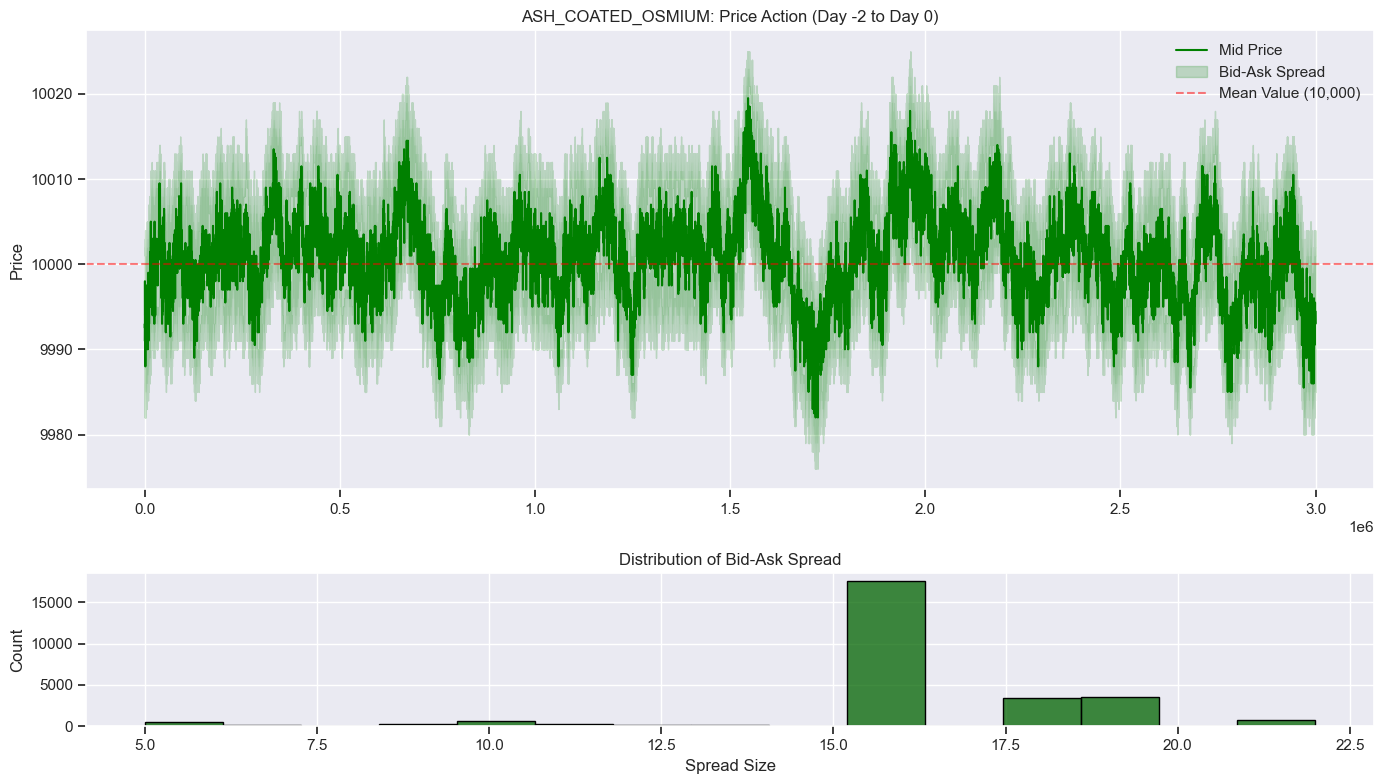

In [33]:
# ASH_COATED_OSMIUM
osmium_prices = valid_prices[valid_prices['product'] == 'ASH_COATED_OSMIUM']
osmium_trades = valid_prices[valid_prices['product'] == 'ASH_COATED_OSMIUM']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], color='green', label='Mid Price', linewidth=1.5)
ax1.fill_between(osmium_prices['global_timestamp'], osmium_prices['bid_price_1'], osmium_prices['ask_price_1'], color='green', alpha=0.2, label='Bid-Ask Spread')
ax1.axhline(y=10000, color='red', linestyle='--', alpha=0.5, label='Mean Value (10,000)')
ax1.set_title('ASH_COATED_OSMIUM: Price Action (Day -2 to Day 0)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(osmium_prices['spread'], bins=15, ax=ax2, color='darkgreen')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()


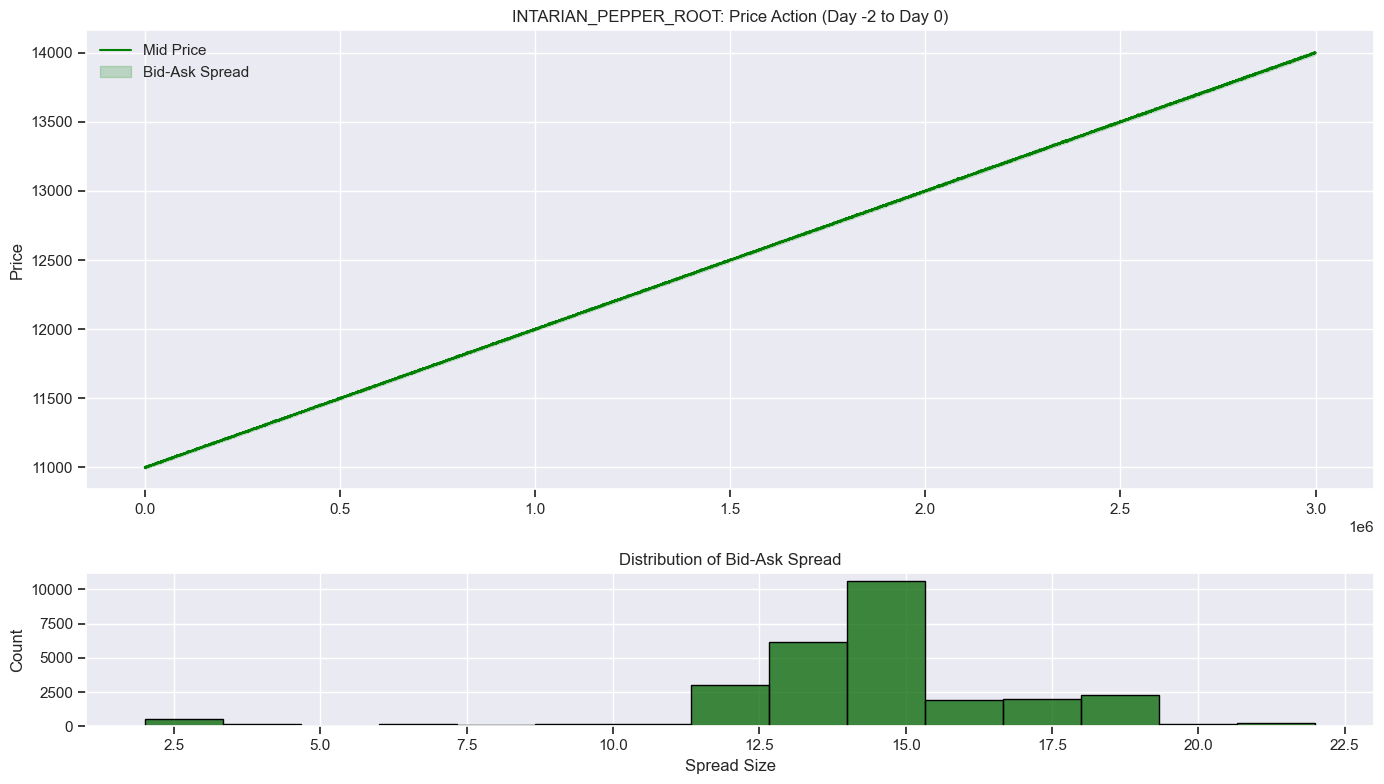

In [34]:
# INTARIAN_PEPPER_ROOT
pepper_prices = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT']
pepper_trades = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], color='green', label='Mid Price', linewidth=1.5)
ax1.fill_between(pepper_prices['global_timestamp'], pepper_prices['bid_price_1'], pepper_prices['ask_price_1'], color='green', alpha=0.2, label='Bid-Ask Spread')
ax1.set_title('INTARIAN_PEPPER_ROOT: Price Action (Day -2 to Day 0)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(pepper_prices['spread'], bins=15, ax=ax2, color='darkgreen')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()

`ASH_COATED_OSMIUM` stays clustered around a stable level near 10,000, with only modest fluctuations around that anchor. Its most common spreads are 16, then 19 and 18. That profile is consistent with a product suited to passive spread capture around a fixed fair value.

`INTARIAN_PEPPER_ROOT` price path shows clear within day drift together with distinct daily level shifts.

### 4.3 Simple predictive structure by product

In [36]:
# Simple predictive structure by product
signal_rows = []
for product, g in prices_features.groupby("product"):
    g = g.sort_values(["day", "timestamp"]).copy()
    g["next_mid_change"] = g.groupby("day")["quoted_mid"].shift(-1) - g["quoted_mid"]
    g["mid_change"] = g.groupby("day")["quoted_mid"].diff()

    daily_autocorr = []
    for _, gd in g.groupby("day"):
        daily_autocorr.append(gd["mid_change"].dropna().autocorr(lag=1))

    v = g.dropna(subset=["next_mid_change"])
    signal_rows.append(
        {
            "product": product,
            "lag1_autocorr_mid_change": np.nanmean(daily_autocorr),
            "corr_imbalance_next_move": v["imbalance_l1"].corr(v["next_mid_change"]),
            "avg_next_move_if_imb_pos": v.loc[v["imbalance_l1"] > 0, "next_mid_change"].mean(),
            "avg_next_move_if_imb_neg": v.loc[v["imbalance_l1"] < 0, "next_mid_change"].mean(),
            "avg_next_move_if_imb_zero": v.loc[v["imbalance_l1"] == 0, "next_mid_change"].mean(),
        }
    )

signal_summary = pd.DataFrame(signal_rows)
signal_summary

,product,lag1_autocorr_mid_change,corr_imbalance_next_move,avg_next_move_if_imb_pos,avg_next_move_if_imb_neg,avg_next_move_if_imb_zero
0,ASH_COATED_OSMIUM,-0.442119,0.585653,1.912676,-1.791121,-0.030955
1,INTARIAN_PEPPER_ROOT,-0.455803,0.568328,2.042448,-1.826885,0.095807


**Level 1 imbalance is informative in both products** 

It is useful as a short horizon execution signal even though the broad strategy should still differ by product.

## 5. `INTARIAN_PEPPER_ROOT` research

`INTARIAN_PEPPER_ROOT` is the clearest source of directional edge in the round 2 data. The main question is therefore not whether the product trends, but how that trend should be monetised without giving too much away through poor execution.

Pepper continues to display a remarkably stable upward trend. Across the three sample days, the quoted mid rises by approximately **998**, **1001.5** and **999.5** ticks respectively from the first valid observation to the last. In fact, the relationship between timestamp and price is nearly perfectly linear in sample. The correlation between time and quoted mid exceeds **0.99998** on each day, and the estimated slope is almost exactly **0.001 tick per timestamp unit**.

In practical terms, this means pepper is gaining about **1 tick every 1,000 timestamp units**, or about **1,000 ticks over a full day**. For strategy design, that is a very strong prior. It suggests that the correct default stance in pepper is long biased unless short horizon conditions make immediate execution unattractive.

The key practical implication is that pepper should not be traded as a neutral market making product. A symmetric two sided quoting strategy is likely to work against the dominant opportunity by repeatedly selling inventory in a market that keeps trending upward.

### 5.1 Pepper root diagnostics

In [37]:
# Pepper trend diagnostics
pepper = prices_features[prices_features["product"] == "INTARIAN_PEPPER_ROOT"].dropna(subset=["quoted_mid"]).copy()

trend_rows = []
for day, gd in pepper.groupby("day"):
    gd = gd.sort_values("timestamp")
    slope = np.polyfit(gd["timestamp"].astype(float), gd["quoted_mid"].astype(float), 1)[0]
    corr = gd["timestamp"].corr(gd["quoted_mid"])
    trend_rows.append({"day": day, "corr_time_mid": corr, "slope_per_timestamp_unit": slope})

pepper_trend_summary = pd.DataFrame(trend_rows)
pepper_trend_summary

,day,corr_time_mid,slope_per_timestamp_unit
0,-1,0.999991,0.001
1,0,0.999989,0.001
2,1,0.999988,0.001


In [38]:
# Pepper forward-return profile across horizons
pepper_horizons = []
pepper = prices_features[prices_features["product"] == "INTARIAN_PEPPER_ROOT"].copy()
for h in [1, 5, 10, 20, 50, 100]:
    fut = pepper[f"future_mid_change_{h}"].dropna()
    pepper_horizons.append(
        {
            "horizon": h,
            "mean_future_move": fut.mean(),
            "pct_positive": (fut > 0).mean() * 100,
            "pct_negative": (fut < 0).mean() * 100,
            "pct_zero": (fut == 0).mean() * 100,
        }
    )
pd.DataFrame(pepper_horizons)

,horizon,mean_future_move,pct_positive,pct_negative,pct_zero
0,1,0.094993,34.972486,24.723881,40.303633
1,5,0.497754,63.269531,24.546875,12.183594
2,10,1.000801,75.305795,23.908711,0.785494
3,20,2.001623,90.918335,5.553817,3.527847
4,50,4.994509,97.391645,1.914101,0.694254
5,100,10.001419,99.984230,0.007885,0.007885


### 5.2 Candidate pepper root strategy

The evidence points toward a relatively simple but strongly opinionated design.

Use a **trend anchored fair value** rather than a flat mid based fair value. A natural formulation is

`fair_value = opening_reference + beta * elapsed_time + signal_adjustment - inventory_penalty`

where `beta` captures the average upward drift and `signal_adjustment` comes from level 1 imbalance or microprice. In the sample, `beta` is very close to **0.001 tick per timestamp unit**.

Around this fair value, the strategy should behave asymmetrically:

1. quote more aggressively on the bid than on the ask  
2. tolerate and even seek positive inventory over much of the day  
3. use aggressive buys when the book shows strong immediate continuation signals  
4. sell more selectively, mainly for risk control or when quotes are clearly rich relative to trend adjusted fair value

In other words, pepper should be treated less like a generic market making problem and more like a **directional accumulation problem with disciplined execution**.

## 6. `ASH_COATED_OSMIUM` research

`ASH_COATED_OSMIUM` presents a very different problem from pepper. The product shows no meaningful medium horizon drift, yet it trades actively and exhibits strong short horizon structure at the top of book. This means the main question is how to extract smaller repeated edge while controlling inventory tightly.

Osmium is broadly flat across the three round 2 days. The quoted mid changes by only **+11 ticks** on day `-1`, **+5 ticks** on day `0` and **-15 ticks** on day `1`, for a total start to end move of just **+2 ticks** across the whole sample.

At the same time, osmium is not informationless. Level 1 imbalance remains highly predictive of the next move, and the lag 1 autocorrelation of tick to tick mid changes is strongly negative, which is consistent with short horizon bounce around a local fair value.

### 6.1 Osmium diagnostics

In [40]:
# Osmium forward-return profile across horizons
osmium = prices_features[prices_features["product"] == "ASH_COATED_OSMIUM"].copy()
osmium_horizons = []
for h in [1, 5, 10, 20, 50, 100]:
    fut = osmium[f"future_mid_change_{h}"].dropna()
    osmium_horizons.append(
        {
            "horizon": h,
            "mean_future_move": fut.mean(),
            "pct_positive": (fut > 0).mean() * 100,
            "pct_negative": (fut < 0).mean() * 100,
            "pct_zero": (fut == 0).mean() * 100,
        }
    )
pd.DataFrame(osmium_horizons)

,horizon,mean_future_move,pct_positive,pct_negative,pct_zero
0,1,0.008419,33.886784,33.781302,32.331914
1,5,-0.001895,38.543295,38.187715,23.268990
2,10,-0.000274,40.477680,40.290048,19.232273
3,20,-0.001233,42.440495,41.872847,15.686658
4,50,0.001571,45.123149,43.854343,11.022509
5,100,-0.007486,45.532117,45.895552,8.572332


In [41]:
# Local mean-reversion proxy in osmium: deviation from a 20-snapshot rolling mean versus next move
osmium = osmium.sort_values(["day", "timestamp"]).copy()
osmium["rolling_mean_20"] = (
    osmium.groupby("day")["quoted_mid"].transform(lambda s: s.rolling(20, min_periods=5).mean())
)
osmium["deviation_20"] = osmium["quoted_mid"] - osmium["rolling_mean_20"]
osmium["next_mid_change"] = osmium.groupby("day")["quoted_mid"].shift(-1) - osmium["quoted_mid"]

valid = osmium.dropna(subset=["deviation_20", "next_mid_change"]).copy()
corr_dev_next = valid["deviation_20"].corr(valid["next_mid_change"])

low_cut = valid["deviation_20"].quantile(0.10)
high_cut = valid["deviation_20"].quantile(0.90)

{
    "corr_deviation20_next_move": corr_dev_next,
    "avg_next_move_bottom_decile": valid.loc[valid["deviation_20"] <= low_cut, "next_mid_change"].mean(),
    "avg_next_move_top_decile": valid.loc[valid["deviation_20"] >= high_cut, "next_mid_change"].mean(),
}

{'corr_deviation20_next_move': np.float64(-0.57838766377306),
 'avg_next_move_bottom_decile': np.float64(2.150506230529595),
 'avg_next_move_top_decile': np.float64(-1.8695820433436532)}

### 6.2 Candidate osmium strategy

The evidence points toward a reservation price based market making design.

A natural formulation is

`fair_value = local_anchor + signal_adjustment - inventory_penalty`

where `local_anchor` could be the current quoted mid or a short rolling average, `signal_adjustment` comes from level 1 imbalance or microprice and `inventory_penalty` is relatively strong.

Around this fair value, the strategy should:

1. quote both sides most of the time  
2. skew quotes in the direction implied by imbalance  
3. use aggressive trades only when the book is materially offside relative to fair value or when inventory control requires it  
4. reduce inventory back toward flat more quickly than in pepper

Conceptually, osmium should be treated as a **short horizon market making product with selective signal based aggression**.

### 6.3 Cross product strategy design

At the highest level, the `run()` function should follow the same sequence for both products:

1. read the current order book and current position  
2. compute a product specific fair value  
3. compare market prices with that fair value to identify whether any existing quotes are attractive enough to take aggressively  
4. place passive quotes around the fair value, with placement skewed by both signal and inventory  
5. apply size controls so that orders respect the position limit of 80

#### Product-specific differences

**Pepper root**
- fair value includes a trend component  
- aggressive buys are justified more often than aggressive sells  
- inventory control tolerates positive holdings  
- passive quotes should be asymmetric, with stronger bid exposure

**Osmium**
- fair value is local rather than trend based  
- two sided quoting remains the default  
- inventory should revert toward flat more quickly  
- aggressive taking should be selective

## 7. Valuing extra market access

Round 2 adds a new strategic decision: whether access to the extra 25% of quotes is worth paying for. The relevant question is whether it creates enough *incremental* PnL for our specific strategy to justify a positive Market Access Fee bid. So we should answer whether our strategy is currently **liquidity constrained** or **signal constrained**.

#### Economic intuition

If a strategy already knows what it wants to do but cannot get enough size at attractive prices, extra access has real value.

If a strategy is mainly limited by forecasting quality or by position limits, extra access has much less value.

The round 2 data suggest that our strategy is only partially liquidity constrained. Pepper should benefit more than osmium, but even in pepper the main edge appears to be the persistent drift itself rather than an inability to find any liquidity at all.

### 7.1 Execution-value heuristic for pepper root

In [43]:
# How quickly can we reach 64 units versus 80 units using visible ask depth?
pepper = prices_features[prices_features["product"] == "INTARIAN_PEPPER_ROOT"].copy()

def time_to_reach_qty(df, qty_target, levels=(1,)):
    out = []
    for day, gd in df.groupby("day"):
        gd = gd.sort_values("timestamp").copy()
        avail = 0
        for _, row in gd.iterrows():
            add = 0
            for lvl in levels:
                v = row.get(f"ask_volume_{lvl}", np.nan)
                if pd.notna(v):
                    add += v
            avail += add
            if avail >= qty_target:
                out.append({"day": day, "timestamp_reached": row["timestamp"]})
                break
    return pd.DataFrame(out)

reach_64_l1 = time_to_reach_qty(pepper, 64, levels=(1,))
reach_80_l1 = time_to_reach_qty(pepper, 80, levels=(1,))
reach_64_l12 = time_to_reach_qty(pepper, 64, levels=(1, 2))
reach_80_l12 = time_to_reach_qty(pepper, 80, levels=(1, 2))

{
    "reach_64_using_l1": reach_64_l1.to_dict("records"),
    "reach_80_using_l1": reach_80_l1.to_dict("records"),
    "reach_64_using_l1_l2": reach_64_l12.to_dict("records"),
    "reach_80_using_l1_l2": reach_80_l12.to_dict("records"),
}

{'reach_64_using_l1': [{'day': -1, 'timestamp_reached': 300},
  {'day': 0, 'timestamp_reached': 500},
  {'day': 1, 'timestamp_reached': 500}],
 'reach_80_using_l1': [{'day': -1, 'timestamp_reached': 500},
  {'day': 0, 'timestamp_reached': 600},
  {'day': 1, 'timestamp_reached': 700}],
 'reach_64_using_l1_l2': [{'day': -1, 'timestamp_reached': 200},
  {'day': 0, 'timestamp_reached': 100},
  {'day': 1, 'timestamp_reached': 100}],
 'reach_80_using_l1_l2': [{'day': -1, 'timestamp_reached': 200},
  {'day': 0, 'timestamp_reached': 200},
  {'day': 1, 'timestamp_reached': 200}]}

Three preliminary conclusions.

1. extra market access is worth more in pepper root than in osmium  
2. even in pepper root the benefit appears to be incremental rather than transformative, because the default book is already deep enough to establish the intended position quickly  
3. our private value for access is therefore likely modest to moderate, not extremely high

A useful heuristic is

$$\text{value of full access} ≈ 0.25 \times \lambda \times \text{baseline trading PnL}$$

where $λ$ is the share of our PnL that is genuinely liquidity constrained. The data suggest that $λ$ is well below 1 for our combined strategy.

### 7.2 Market Access Fee bidding framework

Let's convert our private value into an actual bid. This is a game theory problem rather than a pure valuation problem. We do not need to submit the highest bid just need to finish in the **top 50%** of participants.

A useful decision rule is

$$ \text{Expected value of bid b} = \text{P(accept | b)} × \text{(V -- b)}$$

where $V$ is our private value of receiving access.

This expression makes the trade off explicit:

- as $\text{b}$ rises, the probability of acceptance increases  
- but conditional profit if accepted, $\text{V -- b}$, falls

So the optimal bid is typically an interior solution. Bidding too low risks missing out on profitable access. Bidding too high may secure access, but surrender most or all of the value.

We've decided to go with **Market Access Fee bid: 1,501 XIRECs**. This is high enough to contend for a finish in the top 50%, but still remains comfortably below the level where access would materially erode expected profit if accepted.

## 8. Final strategy

### 8.1 Version 1

Putting the research together into a `Trader` class gives the first testable version of the algorithm. The aim of Version 1 is not to be fully optimised. It is to check whether the regime analysis and signal ranking translate into a coherent live policy.

#### 8.1.1 Version 1 trader class

In [ ]:
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List, Optional, Tuple
import json
import math


class Trader:
    PRODUCTS = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]
    LIMITS = {
        "INTARIAN_PEPPER_ROOT": 80,
        "ASH_COATED_OSMIUM": 80,
    }

    # Pepper research: very stable upward drift of ~1000 ticks per day
    # with timestamps stepping by 100, so ~0.001 tick per timestamp unit.
    PEPPER_TREND_SLOPE = 0.001

    def bid(self):
        # Market Access Fee bid from the notebook conclusion.
        return 1501

    def run(self, state: TradingState):
        memory = self._load_memory(state.traderData)

        # Daily reset: Prosperity timestamps restart from 0 each day.
        if state.timestamp == 0:
            memory = {
                "pepper_open_mid": None,
                "ema_mid": {},
                "last_timestamp": 0,
            }

        orders: Dict[str, List[Order]] = {p: [] for p in self.PRODUCTS}

        for product in self.PRODUCTS:
            depth = state.order_depths.get(product)
            if depth is None:
                continue

            position = state.position.get(product, 0)
            best_bid, best_bid_vol, best_ask, best_ask_vol = self._best_prices(depth)
            mid = self._mid_from_book(best_bid, best_ask)
            if mid is None:
                continue

            imbalance = self._imbalance(best_bid_vol, best_ask_vol)
            ema_mid = self._update_ema(memory, product, mid)

            if product == "INTARIAN_PEPPER_ROOT":
                if memory.get("pepper_open_mid") is None:
                    memory["pepper_open_mid"] = mid
                fair = self._pepper_fair_value(
                    timestamp=state.timestamp,
                    mid=mid,
                    imbalance=imbalance,
                    position=position,
                    open_mid=memory["pepper_open_mid"],
                )
                product_orders = self._trade_pepper(
                    product=product,
                    depth=depth,
                    position=position,
                    fair=fair,
                    best_bid=best_bid,
                    best_ask=best_ask,
                )
            else:
                fair = self._osmium_fair_value(
                    ema_mid=ema_mid,
                    mid=mid,
                    imbalance=imbalance,
                    position=position,
                )
                product_orders = self._trade_osmium(
                    product=product,
                    depth=depth,
                    position=position,
                    fair=fair,
                    best_bid=best_bid,
                    best_ask=best_ask,
                )

            orders[product].extend(product_orders)

        memory["last_timestamp"] = state.timestamp
        trader_data = json.dumps(memory)

        return orders, 0, trader_data

    def _load_memory(self, trader_data: str) -> dict:
        if not trader_data:
            return {
                "pepper_open_mid": None,
                "ema_mid": {},
                "last_timestamp": 0,
            }
        try:
            loaded = json.loads(trader_data)
            if not isinstance(loaded, dict):
                raise ValueError("Memory is not a dictionary")
            loaded.setdefault("pepper_open_mid", None)
            loaded.setdefault("ema_mid", {})
            loaded.setdefault("last_timestamp", 0)
            return loaded
        except Exception:
            return {
                "pepper_open_mid": None,
                "ema_mid": {},
                "last_timestamp": 0,
            }

    def _best_prices(
        self, depth: OrderDepth
    ) -> Tuple[Optional[int], int, Optional[int], int]:
        best_bid = max(depth.buy_orders.keys()) if depth.buy_orders else None
        best_ask = min(depth.sell_orders.keys()) if depth.sell_orders else None
        best_bid_vol = depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        # sell side volumes are negative in Prosperity datamodel
        best_ask_vol = -depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0
        return best_bid, best_bid_vol, best_ask, best_ask_vol

    def _mid_from_book(
        self, best_bid: Optional[int], best_ask: Optional[int]
    ) -> Optional[float]:
        if best_bid is not None and best_ask is not None:
            return 0.5 * (best_bid + best_ask)
        if best_bid is not None:
            return float(best_bid)
        if best_ask is not None:
            return float(best_ask)
        return None

    def _imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def _update_ema(self, memory: dict, product: str, mid: float) -> float:
        alpha = 0.15
        prev = memory["ema_mid"].get(product)
        ema = mid if prev is None else alpha * mid + (1.0 - alpha) * prev
        memory["ema_mid"][product] = ema
        return ema

    def _pepper_fair_value(
        self,
        timestamp: int,
        mid: float,
        imbalance: float,
        position: int,
        open_mid: float,
    ) -> float:
        trend_anchor = open_mid + self.PEPPER_TREND_SLOPE * timestamp

        # Structural long bias from the notebook: trend + mild positive carry.
        base = 0.65 * trend_anchor + 0.35 * mid + 4.0
        signal = 5.5 * imbalance

        # Asymmetric inventory treatment: comfortable with modest longs,
        # but strongly dislike being short in pepper.
        if position >= 0:
            inv_penalty = 0.08 * position
        else:
            inv_penalty = 0.22 * position

        return base + signal - inv_penalty

    def _osmium_fair_value(
        self,
        ema_mid: float,
        mid: float,
        imbalance: float,
        position: int,
    ) -> float:
        local_anchor = 0.7 * ema_mid + 0.3 * mid
        signal = 4.7 * imbalance
        inv_penalty = 0.20 * position
        return local_anchor + signal - inv_penalty

    def _trade_pepper(
        self,
        product: str,
        depth: OrderDepth,
        position: int,
        fair: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> List[Order]:
        limit = self.LIMITS[product]
        orders: List[Order] = []
        pos = position

        # Aggressive execution: easier to justify buying than selling in pepper.
        buy_take_edge = 1.5
        sell_take_edge = 4.0

        for ask in sorted(depth.sell_orders.keys()):
            ask_qty = -depth.sell_orders[ask]
            if ask <= fair - buy_take_edge and pos < limit:
                qty = min(ask_qty, limit - pos)
                if qty > 0:
                    orders.append(Order(product, ask, qty))
                    pos += qty

        for bid in sorted(depth.buy_orders.keys(), reverse=True):
            bid_qty = depth.buy_orders[bid]
            if bid >= fair + sell_take_edge and pos > -limit:
                qty = min(bid_qty, pos + limit)
                if qty > 0:
                    orders.append(Order(product, bid, -qty))
                    pos -= qty

        # Passive quoting: stronger bid than ask to preserve long bias.
        if pos < 0:
            bid_size, ask_size = 16, 0
        elif pos < 40:
            bid_size, ask_size = 12, 4
        elif pos < 70:
            bid_size, ask_size = 8, 6
        else:
            bid_size, ask_size = 4, 12

        bid_size = min(bid_size, limit - pos)
        ask_size = min(ask_size, pos + limit)

        bid_width = 5.0
        ask_width = 9.0
        bid_px = self._passive_bid_price(
            fair=fair,
            width=bid_width,
            best_bid=best_bid,
            best_ask=best_ask,
        )
        ask_px = self._passive_ask_price(
            fair=fair,
            width=ask_width,
            best_bid=best_bid,
            best_ask=best_ask,
        )

        if bid_size > 0 and bid_px is not None:
            orders.append(Order(product, bid_px, bid_size))
        if ask_size > 0 and ask_px is not None:
            orders.append(Order(product, ask_px, -ask_size))

        return orders

    def _trade_osmium(
        self,
        product: str,
        depth: OrderDepth,
        position: int,
        fair: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> List[Order]:
        limit = self.LIMITS[product]
        orders: List[Order] = []
        pos = position

        # Aggression is more selective in osmium.
        take_edge = 2.0

        for ask in sorted(depth.sell_orders.keys()):
            ask_qty = -depth.sell_orders[ask]
            if ask <= fair - take_edge and pos < limit:
                qty = min(ask_qty, limit - pos)
                if qty > 0:
                    orders.append(Order(product, ask, qty))
                    pos += qty

        for bid in sorted(depth.buy_orders.keys(), reverse=True):
            bid_qty = depth.buy_orders[bid]
            if bid >= fair + take_edge and pos > -limit:
                qty = min(bid_qty, pos + limit)
                if qty > 0:
                    orders.append(Order(product, bid, -qty))
                    pos -= qty

        # Symmetric inventory-aware quoting around local fair value.
        if pos <= -50:
            bid_size, ask_size = 12, 3
        elif pos < -15:
            bid_size, ask_size = 10, 6
        elif pos <= 15:
            bid_size, ask_size = 9, 9
        elif pos < 50:
            bid_size, ask_size = 6, 10
        else:
            bid_size, ask_size = 3, 12

        bid_size = min(bid_size, limit - pos)
        ask_size = min(ask_size, pos + limit)

        width = 8.0
        bid_px = self._passive_bid_price(
            fair=fair,
            width=width,
            best_bid=best_bid,
            best_ask=best_ask,
        )
        ask_px = self._passive_ask_price(
            fair=fair,
            width=width,
            best_bid=best_bid,
            best_ask=best_ask,
        )

        if bid_size > 0 and bid_px is not None:
            orders.append(Order(product, bid_px, bid_size))
        if ask_size > 0 and ask_px is not None:
            orders.append(Order(product, ask_px, -ask_size))

        return orders

    def _passive_bid_price(
        self,
        fair: float,
        width: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> Optional[int]:
        bid_px = math.floor(fair - width)
        if best_bid is not None:
            if best_ask is not None and best_ask - best_bid > 2:
                bid_px = max(bid_px, best_bid + 1)
            else:
                bid_px = max(bid_px, best_bid)
        if best_ask is not None:
            bid_px = min(bid_px, best_ask - 1)
        return bid_px if best_ask is None or bid_px < best_ask else None

    def _passive_ask_price(
        self,
        fair: float,
        width: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> Optional[int]:
        ask_px = math.ceil(fair + width)
        if best_ask is not None:
            if best_bid is not None and best_ask - best_bid > 2:
                ask_px = min(ask_px, best_ask - 1)
            else:
                ask_px = min(ask_px, best_ask)
        if best_bid is not None:
            ask_px = max(ask_px, best_bid + 1)
        return ask_px if best_bid is None or ask_px > best_bid else None

#### 8.1.2 Version 1 performance

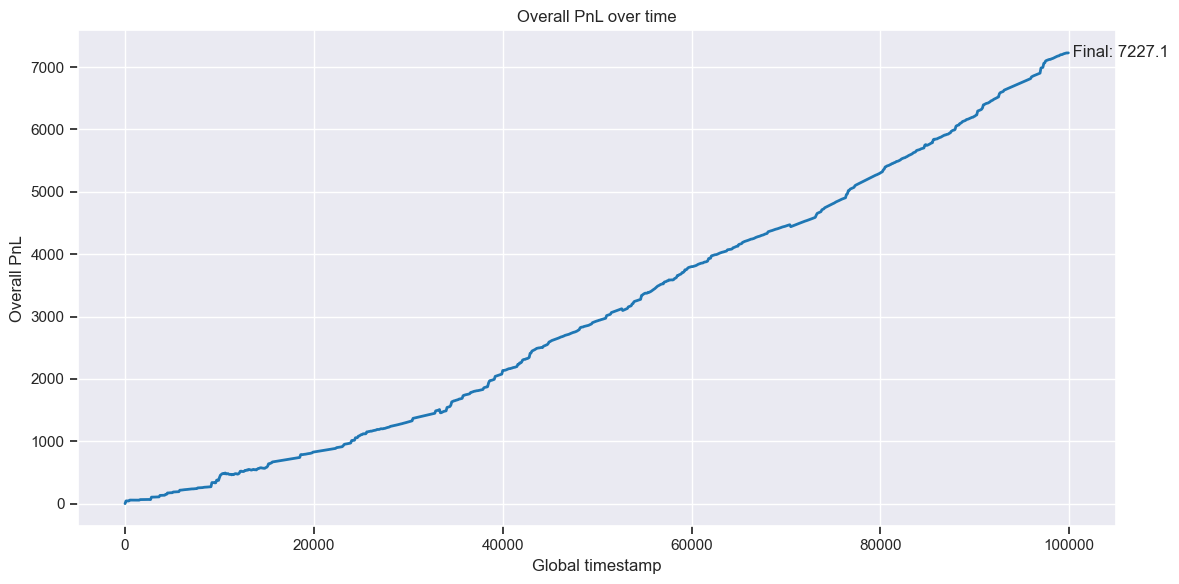

In [44]:
path = "data/version_1.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v1 = json.load(f)

df_performance_v1 = pd.read_csv(StringIO(raw_v1["activitiesLog"]), sep=";")

df_performance_v1["global_timestamp"] = (df_performance_v1["day"] - df_performance_v1["day"].min()) * DAY_LENGTH + df_performance_v1["timestamp"]

overall_pnl = (
    df_performance_v1.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

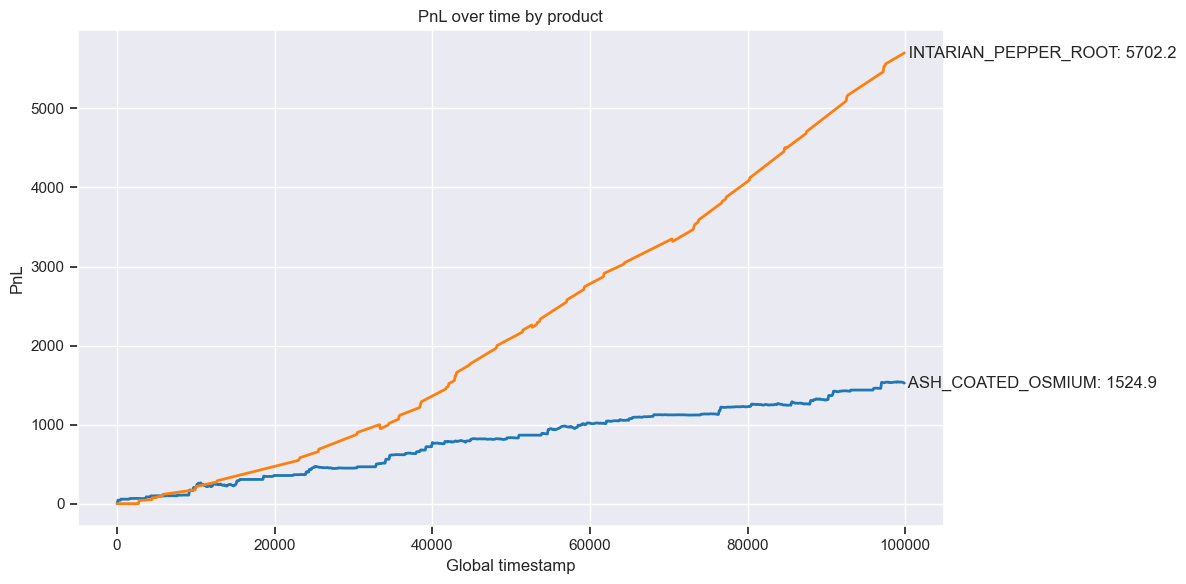

In [45]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v1.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [50]:
df_trades_v1 = pd.DataFrame(raw_v1['tradeHistory'])

df_trades_v1['signed_qty']=np.where(df_trades_v1['buyer']=='SUBMISSION', df_trades_v1['quantity'],
                                     np.where(df_trades_v1['seller']=='SUBMISSION', -df_trades_v1['quantity'], 0))
df_trades_v1['cashflow']= -df_trades_v1['signed_qty']*df_trades_v1['price'] 

metrics = {}

for prod,g in df_trades_v1.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    g['pos'] = g['signed_qty'].cumsum()
    first_buy = g.loc[g["signed_qty"] > 0, "timestamp"].min() if (g["signed_qty"] > 0).any() else np.nan
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': g['pos'].abs().max(),
        'cash_pnl': g['cashflow'].sum(),
        'first_buy_timestamp': first_buy,
        'avg_position_at_trade_times': g['pos'].mean(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl,first_buy_timestamp,avg_position_at_trade_times
ASH_COATED_OSMIUM,68.0,32.0,35.0,164.0,171.0,9999.067073,10008.134503,-7.0,23.0,71544.0,0.0,4.970588
INTARIAN_PEPPER_ROOT,57.0,28.0,20.0,166.0,108.0,13042.710843,13064.796296,58.0,77.0,-754092.0,2700.0,50.052632


Drawdowns:

In [47]:
df_performance_v1_wide = df_performance_v1.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v1_wide['total']=df_performance_v1_wide.sum(axis=1)
dd = df_performance_v1_wide['total'] - df_performance_v1_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v1_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,1524.867188,1542.140625,0.0,-47.937500,11900.0
INTARIAN_PEPPER_ROOT,5702.250000,5702.250000,0.0,-51.687500,33400.0
total,7227.117188,7227.117188,0.0,-52.507812,33400.0


Version 1 is already a solid baseline. Final total PnL is **7227**, made up of about **1525** from `ASH_COATED_OSMIUM` and **5702** from `INTARIAN_PEPPER_ROOT`.

The main issue in Version 1 was not osmium. It was that pepper never got long enough, early enough and then sold too much into a market that kept drifting upward.

Key observations from the log:

- the first pepper buy happened only at timestamp 2700 
- pepper average position at trade times was around 51.2, well below what the 80 limit allowed  
- pepper bought 166 units but also sold 108, which was too much recycling in a rising market

### 8.2 Version 2

#### 8.2.1 Version 2 trader class

Main changes from Version 1:

1. pepper root gained an explicit **target long inventory**  
2. pepper root buys became more aggressive  
3. pepper root passive bids became tighter  
4. pepper root asks were pushed much further away, so the strategy stopped recycling long inventory too cheaply

In [ ]:
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List, Optional, Tuple
import json
import math


class Trader:
    PRODUCTS = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]
    LIMITS = {
        "INTARIAN_PEPPER_ROOT": 80,
        "ASH_COATED_OSMIUM": 80,
    }

    # Empirically, pepper drifts upward by about 0.001 per timestamp unit.
    PEPPER_TREND_SLOPE = 0.001

    def bid(self):
        # Balanced MAF bid from the research notebook.
        return 1501

    def run(self, state: TradingState):
        memory = self._load_memory(state.traderData)

        if state.timestamp == 0:
            memory = {
                "pepper_open_mid": None,
                "ema_mid": {},
            }

        orders: Dict[str, List[Order]] = {p: [] for p in self.PRODUCTS}

        for product in self.PRODUCTS:
            depth = state.order_depths.get(product)
            if depth is None:
                continue

            position = state.position.get(product, 0)
            best_bid, best_bid_vol, best_ask, best_ask_vol = self._best_prices(depth)
            mid = self._mid_from_book(best_bid, best_ask)
            if mid is None:
                continue

            imbalance = self._imbalance(best_bid_vol, best_ask_vol)
            ema_mid = self._update_ema(memory, product, mid)

            if product == "INTARIAN_PEPPER_ROOT":
                if memory.get("pepper_open_mid") is None:
                    memory["pepper_open_mid"] = mid

                fair = self._pepper_fair_value(
                    timestamp=state.timestamp,
                    mid=mid,
                    imbalance=imbalance,
                    position=position,
                    open_mid=memory["pepper_open_mid"],
                )
                product_orders = self._trade_pepper(
                    product=product,
                    depth=depth,
                    position=position,
                    fair=fair,
                    best_bid=best_bid,
                    best_ask=best_ask,
                    timestamp=state.timestamp,
                )
            else:
                fair = self._osmium_fair_value(
                    ema_mid=ema_mid,
                    mid=mid,
                    imbalance=imbalance,
                    position=position,
                )
                product_orders = self._trade_osmium(
                    product=product,
                    depth=depth,
                    position=position,
                    fair=fair,
                    best_bid=best_bid,
                    best_ask=best_ask,
                )

            orders[product].extend(product_orders)

        trader_data = json.dumps(memory)
        return orders, 0, trader_data

    def _load_memory(self, trader_data: str) -> dict:
        if not trader_data:
            return {
                "pepper_open_mid": None,
                "ema_mid": {},
            }
        try:
            loaded = json.loads(trader_data)
            if not isinstance(loaded, dict):
                raise ValueError("Memory is not a dictionary")
            loaded.setdefault("pepper_open_mid", None)
            loaded.setdefault("ema_mid", {})
            return loaded
        except Exception:
            return {
                "pepper_open_mid": None,
                "ema_mid": {},
            }

    def _best_prices(
        self, depth: OrderDepth
    ) -> Tuple[Optional[int], int, Optional[int], int]:
        best_bid = max(depth.buy_orders.keys()) if depth.buy_orders else None
        best_ask = min(depth.sell_orders.keys()) if depth.sell_orders else None
        best_bid_vol = depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        best_ask_vol = -depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0
        return best_bid, best_bid_vol, best_ask, best_ask_vol

    def _mid_from_book(
        self, best_bid: Optional[int], best_ask: Optional[int]
    ) -> Optional[float]:
        if best_bid is not None and best_ask is not None:
            return 0.5 * (best_bid + best_ask)
        if best_bid is not None:
            return float(best_bid)
        if best_ask is not None:
            return float(best_ask)
        return None

    def _imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def _update_ema(self, memory: dict, product: str, mid: float) -> float:
        alpha = 0.18
        prev = memory["ema_mid"].get(product)
        ema = mid if prev is None else alpha * mid + (1.0 - alpha) * prev
        memory["ema_mid"][product] = ema
        return ema

    def _pepper_target_position(self, timestamp: int) -> int:
        # Hold a large long in pepper for most of the session.
        if timestamp < 15000:
            return 70
        if timestamp < 85000:
            return 80
        return 70

    def _pepper_fair_value(
        self,
        timestamp: int,
        mid: float,
        imbalance: float,
        position: int,
        open_mid: float,
    ) -> float:
        trend_anchor = open_mid + self.PEPPER_TREND_SLOPE * timestamp
        target_pos = self._pepper_target_position(timestamp)

        # Stronger long bias than V1:
        #   - trend anchor
        #   - mild premium
        #   - positive adjustment when under target inventory
        base = 0.55 * trend_anchor + 0.45 * mid + 6.0
        signal = 7.5 * imbalance
        inventory_push = 0.18 * (target_pos - position)

        return base + signal + inventory_push

    def _osmium_fair_value(
        self,
        ema_mid: float,
        mid: float,
        imbalance: float,
        position: int,
    ) -> float:
        local_anchor = 0.75 * ema_mid + 0.25 * mid
        signal = 4.8 * imbalance
        inv_penalty = 0.22 * position
        return local_anchor + signal - inv_penalty

    def _trade_pepper(
        self,
        product: str,
        depth: OrderDepth,
        position: int,
        fair: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
        timestamp: int,
    ) -> List[Order]:
        limit = self.LIMITS[product]
        orders: List[Order] = []
        pos = position
        target_pos = self._pepper_target_position(timestamp)

        # More aggressive accumulation than V1.
        buy_take_edge = 0.5
        sell_take_edge = 8.0

        for ask in sorted(depth.sell_orders.keys()):
            ask_qty = -depth.sell_orders[ask]
            if ask <= fair - buy_take_edge and pos < limit:
                qty = min(ask_qty, limit - pos)
                if qty > 0:
                    orders.append(Order(product, ask, qty))
                    pos += qty

        # Only sell when the bid is genuinely rich or we are very full.
        for bid in sorted(depth.buy_orders.keys(), reverse=True):
            bid_qty = depth.buy_orders[bid]
            rich_enough = bid >= fair + sell_take_edge
            reducing_overfill = pos > target_pos + 8 and bid >= fair + 4.0
            if (rich_enough or reducing_overfill) and pos > -limit:
                qty = min(bid_qty, pos + limit)
                if qty > 0:
                    orders.append(Order(product, bid, -qty))
                    pos -= qty

        # Passive quoting:
        # overwhelmingly prefer bid exposure, especially while below target.
        if pos < target_pos - 30:
            bid_size, ask_size = 20, 0
        elif pos < target_pos - 10:
            bid_size, ask_size = 14, 0
        elif pos < target_pos + 5:
            bid_size, ask_size = 10, 2
        elif pos < 78:
            bid_size, ask_size = 6, 4
        else:
            bid_size, ask_size = 2, 8

        bid_size = min(bid_size, limit - pos)
        ask_size = min(ask_size, pos + limit)

        # Bid more tightly than V1 so we get long earlier.
        if pos < target_pos - 10:
            bid_width = 2.0
        else:
            bid_width = 3.0
        ask_width = 14.0

        bid_px = self._passive_bid_price(
            fair=fair,
            width=bid_width,
            best_bid=best_bid,
            best_ask=best_ask,
        )
        ask_px = self._passive_ask_price(
            fair=fair,
            width=ask_width,
            best_bid=best_bid,
            best_ask=best_ask,
        )

        if bid_size > 0 and bid_px is not None:
            orders.append(Order(product, bid_px, bid_size))
        if ask_size > 0 and ask_px is not None:
            orders.append(Order(product, ask_px, -ask_size))

        return orders

    def _trade_osmium(
        self,
        product: str,
        depth: OrderDepth,
        position: int,
        fair: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> List[Order]:
        limit = self.LIMITS[product]
        orders: List[Order] = []
        pos = position

        take_edge = 2.0

        for ask in sorted(depth.sell_orders.keys()):
            ask_qty = -depth.sell_orders[ask]
            if ask <= fair - take_edge and pos < limit:
                qty = min(ask_qty, limit - pos)
                if qty > 0:
                    orders.append(Order(product, ask, qty))
                    pos += qty

        for bid in sorted(depth.buy_orders.keys(), reverse=True):
            bid_qty = depth.buy_orders[bid]
            if bid >= fair + take_edge and pos > -limit:
                qty = min(bid_qty, pos + limit)
                if qty > 0:
                    orders.append(Order(product, bid, -qty))
                    pos -= qty

        if pos <= -50:
            bid_size, ask_size = 12, 3
        elif pos < -15:
            bid_size, ask_size = 10, 6
        elif pos <= 15:
            bid_size, ask_size = 9, 9
        elif pos < 50:
            bid_size, ask_size = 6, 10
        else:
            bid_size, ask_size = 3, 12

        bid_size = min(bid_size, limit - pos)
        ask_size = min(ask_size, pos + limit)

        width = 8.0
        bid_px = self._passive_bid_price(
            fair=fair,
            width=width,
            best_bid=best_bid,
            best_ask=best_ask,
        )
        ask_px = self._passive_ask_price(
            fair=fair,
            width=width,
            best_bid=best_bid,
            best_ask=best_ask,
        )

        if bid_size > 0 and bid_px is not None:
            orders.append(Order(product, bid_px, bid_size))
        if ask_size > 0 and ask_px is not None:
            orders.append(Order(product, ask_px, -ask_size))

        return orders

    def _passive_bid_price(
        self,
        fair: float,
        width: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> Optional[int]:
        bid_px = math.floor(fair - width)
        if best_bid is not None:
            if best_ask is not None and best_ask - best_bid > 2:
                bid_px = max(bid_px, best_bid + 1)
            else:
                bid_px = max(bid_px, best_bid)
        if best_ask is not None:
            bid_px = min(bid_px, best_ask - 1)
        return bid_px if best_ask is None or bid_px < best_ask else None

    def _passive_ask_price(
        self,
        fair: float,
        width: float,
        best_bid: Optional[int],
        best_ask: Optional[int],
    ) -> Optional[int]:
        ask_px = math.ceil(fair + width)
        if best_ask is not None:
            if best_bid is not None and best_ask - best_bid > 2:
                ask_px = min(ask_px, best_ask - 1)
            else:
                ask_px = min(ask_px, best_ask)
        if best_bid is not None:
            ask_px = max(ask_px, best_bid + 1)
        return ask_px if best_bid is None or ask_px > best_bid else None


#### 8.2.2 Version 2 performance

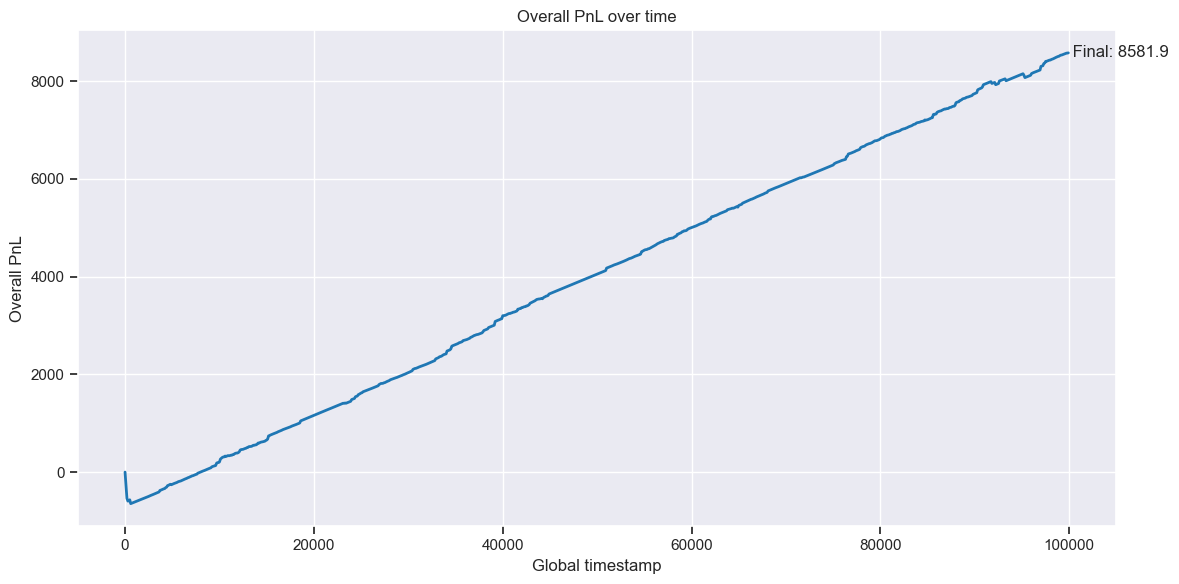

In [51]:
path = "data/version_2.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v2 = json.load(f)

df_performance_v2 = pd.read_csv(StringIO(raw_v2["activitiesLog"]), sep=";")

df_performance_v2["global_timestamp"] = (df_performance_v2["day"] - df_performance_v2["day"].min()) * DAY_LENGTH + df_performance_v2["timestamp"]

overall_pnl = (
    df_performance_v2.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

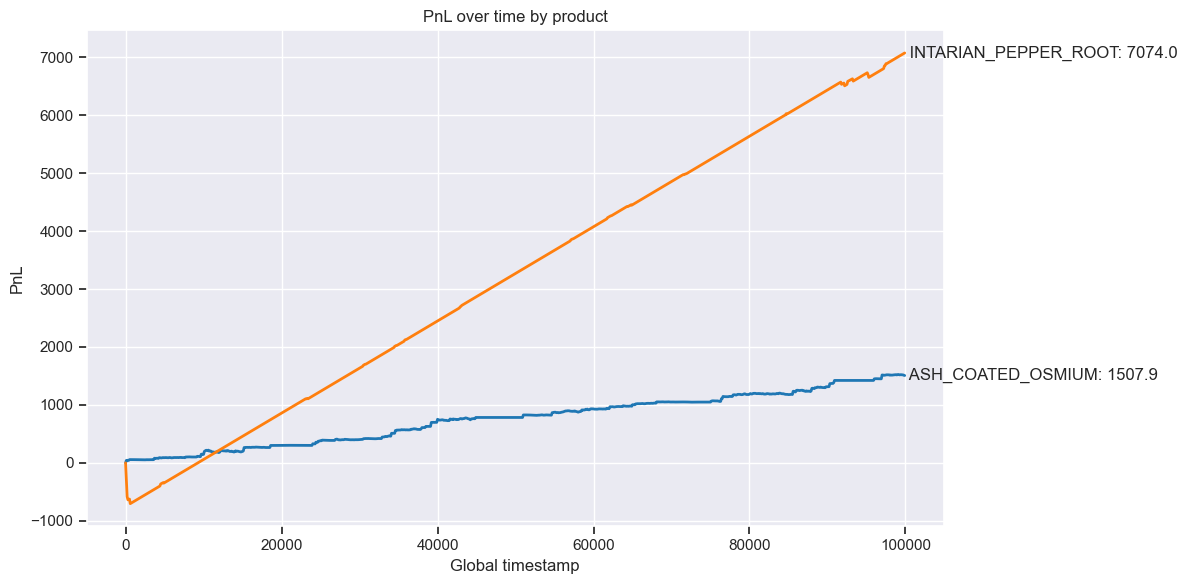

In [52]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v2.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [53]:
df_trades_v2 = pd.DataFrame(raw_v2['tradeHistory'])

df_trades_v2['signed_qty']=np.where(df_trades_v2['buyer']=='SUBMISSION', df_trades_v2['quantity'],
                                     np.where(df_trades_v2['seller']=='SUBMISSION', -df_trades_v2['quantity'], 0))
df_trades_v2['cashflow']= -df_trades_v2['signed_qty']*df_trades_v2['price'] 

metrics = {}

for prod,g in df_trades_v2.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    g['pos'] = g['signed_qty'].cumsum()
    first_buy = g.loc[g["signed_qty"] > 0, "timestamp"].min() if (g["signed_qty"] > 0).any() else np.nan
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': g['pos'].abs().max(),
        'cash_pnl': g['cashflow'].sum(),
        'first_buy_timestamp': first_buy,
        'avg_position_at_trade_times': g['pos'].mean(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl,first_buy_timestamp,avg_position_at_trade_times
ASH_COATED_OSMIUM,66.0,30.0,36.0,162.0,169.0,9998.969136,10008.047337,-7.0,21.0,71527.0,0.0,4.530303
INTARIAN_PEPPER_ROOT,57.0,23.0,15.0,135.0,55.0,13035.955556,13071.563636,80.0,80.0,-1040918.0,0.0,75.894737


Drawdowns:

In [54]:
df_performance_v2_wide = df_performance_v2.pivot(index='global_timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v2_wide['total']=df_performance_v2_wide.sum(axis=1)
dd = df_performance_v2_wide['total'] - df_performance_v2_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v2_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,1507.867188,1525.140625,0.000000,-41.984375,11900.0
INTARIAN_PEPPER_ROOT,7074.000000,7074.000000,-703.000000,-703.000000,600.0
total,8581.867188,8581.867188,-645.886719,-645.886719,600.0


Version 2 is already a solid baseline. Final total PnL is **8618**, made up of about **1376** from `ASH_COATED_OSMIUM` and **7242** from `INTARIAN_PEPPER_ROOT`.

The main issue in Version 1 was not osmium. It was that pepper never got long enough, early enough and then sold too much into a market that kept drifting upward.

Key observations from the V2 log:

- the first pepper buy happened immediately at timestamp 0  
- pepper average position at trade times rose to around 73.8  
- pepper total sells fell sharply from 108 to 49 
- pepper ended the session at the full 80 unit long position

Osmium remained profitable, but the log suggested that any further improvement there would likely come from execution refinement rather than from inventing a new signal. In particular, the safest next step would be to improve fair value blending, adaptive quote width and inventory skew, rather than building a more complex predictive model.

Pepper root can be improved further by avoiding trading at the very very early timestamps.

### 8.3 Round 2 performance

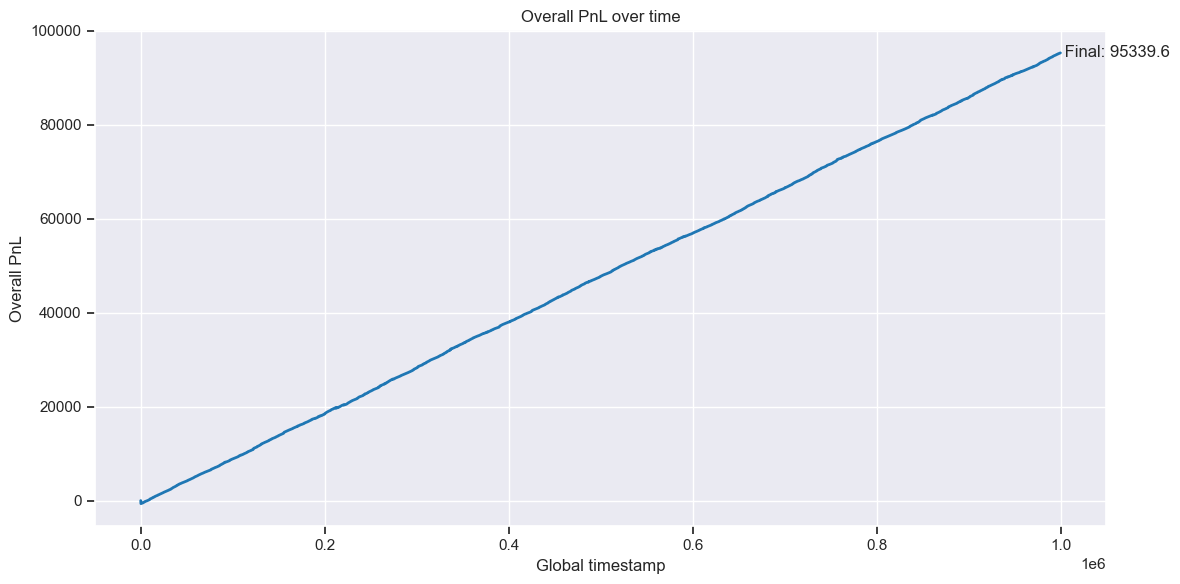

In [55]:
path = "data/r2_test.log"
with open(path, "r", encoding="utf-8") as f:
    raw_r2 = json.load(f)

df_performance_r2 = pd.read_csv(StringIO(raw_r2["activitiesLog"]), sep=";")

df_performance_r2["global_timestamp"] = (df_performance_r2["day"] - df_performance_r2["day"].min()) * DAY_LENGTH + df_performance_r2["timestamp"]

overall_pnl = (
    df_performance_r2.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

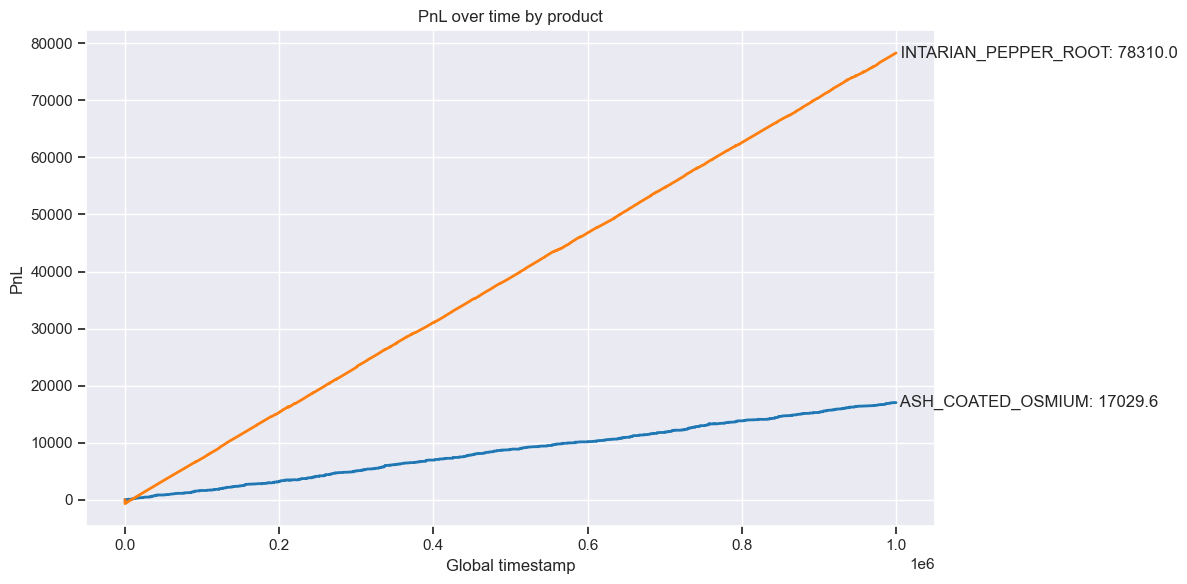

In [57]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_r2.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [58]:
df_trades_r2 = pd.DataFrame(raw_r2['tradeHistory'])

df_trades_r2['signed_qty']=np.where(df_trades_r2['buyer']=='SUBMISSION', df_trades_r2['quantity'],
                                     np.where(df_trades_r2['seller']=='SUBMISSION', -df_trades_r2['quantity'], 0))
df_trades_r2['cashflow']= -df_trades_r2['signed_qty']*df_trades_r2['price'] 

metrics = {}

for prod,g in df_trades_r2.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    g['pos'] = g['signed_qty'].cumsum()
    first_buy = g.loc[g["signed_qty"] > 0, "timestamp"].min() if (g["signed_qty"] > 0).any() else np.nan
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': g['pos'].abs().max(),
        'cash_pnl': g['cashflow'].sum(),
        'first_buy_timestamp': first_buy,
        'avg_position_at_trade_times': g['pos'].mean(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl,first_buy_timestamp,avg_position_at_trade_times
ASH_COATED_OSMIUM,675.0,339.0,328.0,1699.0,1690.0,9977.404356,9987.368639,9.0,28.0,-72957.0,0.0,1.949630
INTARIAN_PEPPER_ROOT,536.0,190.0,175.0,934.0,854.0,14488.725910,14532.538642,80.0,80.0,-1121682.0,0.0,76.697761


Drawdowns:

In [59]:
df_performance_r2_wide = df_performance_r2.pivot(index='global_timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_r2_wide['total']=df_performance_r2_wide.sum(axis=1)
dd = df_performance_r2_wide['total'] - df_performance_r2_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_r2_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,17029.617188,17031.960938,0.000000,-81.375000,766400.0
INTARIAN_PEPPER_ROOT,78310.000000,78310.000000,-685.562500,-685.562500,200.0
total,95339.617188,95339.617188,-647.796875,-647.796875,200.0
